In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/abstracts_clean.csv")

print("Dataset size:", len(df))
df.head()

Dataset size: 10000


,id,abstract
0,704.0001,A fully differential calculation in perturba...
1,704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,704.0003,The evolution of Earth-Moon system is descri...
3,704.0006,We study the two-particle wave function of p...
4,704.0007,A rather non-standard quantum representation...


In [2]:
import random

sample_size = 100  # keep small for testing

pairs = []

indices = list(df.index)
random.shuffle(indices)

for i in range(0, sample_size*2, 2):
    text1 = df.loc[indices[i], "abstract"]
    text2 = df.loc[indices[i+1], "abstract"]
    pairs.append((text1, text2))

len(pairs)

100

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

def jaccard_similarity(text1, text2, n=3):
    vectorizer = CountVectorizer(ngram_range=(n,n), binary=True)
    X = vectorizer.fit_transform([text1, text2])
    X = X.toarray()
    
    intersection = np.logical_and(X[0], X[1]).sum()
    union = np.logical_or(X[0], X[1]).sum()
    
    if union == 0:
        return 0
    return intersection / union

In [4]:
jaccard_similarity(pairs[0][0], pairs[0][1])

np.float64(0.0)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def tfidf_similarity(text1, text2):
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform([text1, text2])
    return cosine_similarity(tfidf[0], tfidf[1])[0][0]

In [6]:
tfidf_similarity(pairs[0][0], pairs[0][1])

np.float64(0.299075604546511)

In [7]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

def embedding_similarity(text1, text2):
    emb1 = model.encode(text1)
    emb2 = model.encode(text2)
    return cosine_similarity([emb1], [emb2])[0][0]

2026-02-25 17:49:24.558331: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nyct_cg/ml_env/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [8]:
embedding_similarity(pairs[0][0], pairs[0][1])

np.float32(-0.0046772505)

In [9]:
results = []

for text1, text2 in pairs:
    results.append({
        "jaccard": jaccard_similarity(text1, text2),
        "tfidf": tfidf_similarity(text1, text2),
        "embedding": embedding_similarity(text1, text2)
    })

results_df = pd.DataFrame(results)
results_df.describe()

,jaccard,tfidf,embedding
count,100.000000,100.000000,100.000000
mean,0.000578,0.342950,0.101065
std,0.001862,0.095857,0.113169
min,0.000000,0.098452,-0.132519
25%,0.000000,0.288687,0.020530
50%,0.000000,0.346399,0.091487
75%,0.000000,0.404827,0.166111
max,0.011561,0.587699,0.427586


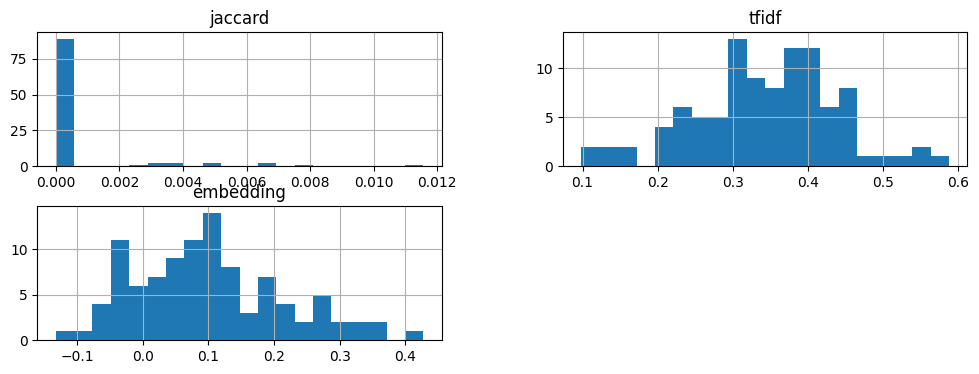

In [10]:
import matplotlib.pyplot as plt

results_df.hist(bins=20, figsize=(12,4))
plt.show()

In [11]:
text = df.loc[0, "abstract"]

In [12]:
print("Jaccard:", jaccard_similarity(text, text))
print("TF-IDF:", tfidf_similarity(text, text))
print("Embedding:", embedding_similarity(text, text))

Jaccard: 1.0
TF-IDF: 0.9999999999999991
Embedding: 1.0
